Project Name 
PhonePe Transaction Insights  

Project Type 
Machine Learning (Regression with EDA)

Contribution
Individual  

Team Member 1 
Shraya A  

Project Summary

The PhonePe Transaction Insights project focuses on analyzing and predicting digital payment trends using real-world transaction data. With the rapid growth of digital payment platforms, understanding transaction behavior, user engagement, and geographical trends has become essential for businesses.

The dataset used in this project is sourced from the PhonePe Pulse GitHub repository, which contains structured JSON data representing transaction details such as states, districts, transaction types, counts, and transaction amounts across multiple years and quarters.

The project begins with data extraction and transformation, where JSON data is loaded into a MySQL database for efficient querying. SQL queries are then used to analyze aggregated values such as total transaction amounts by state, district, and transaction type.

Exploratory Data Analysis (EDA) is performed to uncover key patterns and trends. Various visualizations such as bar charts, line plots, and heatmaps are used to understand the distribution and relationships between variables. Insights such as top-performing states, increasing digital adoption trends, and dominant transaction categories are identified.

The core focus of this project is machine learning. A regression-based approach is used to predict transaction amounts based on features such as year, quarter, and transaction count. Feature engineering techniques are applied to improve model performance, including the creation of derived features like average transaction value.

Multiple machine learning models are implemented, including Linear Regression, Decision Tree Regressor, and Random Forest Regressor. These models are evaluated using performance metrics such as R² score and Mean Squared Error (MSE). Hyperparameter tuning is performed to optimize model performance.

Among the models, Random Forest demonstrated the best performance due to its ability to capture complex relationships in the data. The final model can be used to forecast transaction volumes and support business decision-making.

Overall, this project demonstrates strong skills in data extraction, SQL querying, data visualization, and machine learning. It provides valuable insights that can help businesses improve marketing strategies, enhance user engagement, and optimize product offerings.

GitHub Link
https://github.com/shrayaashok/labmentix_phonepe

Problem Statement

With the increasing adoption of digital payment platforms like PhonePe, there is a need to analyze transaction patterns and predict future trends. Understanding user behavior, regional performance, and transaction categories can help businesses make data-driven decisions.

This project aims to analyze transaction data and build a machine learning model to predict transaction amounts based on historical trends.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector

In [4]:
conn=mysql.connector.connect(host="localhost",user="root",password="1234",database="phone_pe")

In [5]:
df=pd.read_sql("select * from aggregated_transaction",conn)
df.head()

C:\Users\shray\AppData\Local\Temp\ipykernel_14672\3248004227.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql("select * from aggregated_transaction",conn)


,state,year,quarter,transaction_type,transaction_count,transaction_amount
0,andaman-&-nicobar-islands,2018,1,Recharge & bill payments,4200,1.845307e+06
1,andaman-&-nicobar-islands,2018,1,Peer-to-peer payments,1871,1.213866e+07
2,andaman-&-nicobar-islands,2018,1,Merchant payments,298,4.525072e+05
3,andaman-&-nicobar-islands,2018,1,Financial Services,33,1.060142e+04
4,andaman-&-nicobar-islands,2018,1,Others,256,1.846899e+05


In [6]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20136 entries, 0 to 20135
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   state               20136 non-null  object 
 1   year                20136 non-null  int64  
 2   quarter             20136 non-null  int64  
 3   transaction_type    20136 non-null  object 
 4   transaction_count   20136 non-null  int64  
 5   transaction_amount  20136 non-null  float64
dtypes: float64(1), int64(3), object(2)
memory usage: 944.0+ KB


state                 0
year                  0
quarter               0
transaction_type      0
transaction_count     0
transaction_amount    0
dtype: int64

In [ ]:
df.describe()
df.columns


Index(['state', 'year', 'quarter', 'transaction_type', 'transaction_count',
       'transaction_amount'],
      dtype='object')

Variables Description

- state: Name of the state  
- year: Year of transaction  
- quarter: Quarter of transaction  
- transaction_type: Type of payment  
- transaction_count: Number of transactions  
- transaction_amount: Total transaction value  

C:\Users\shray\AppData\Local\Temp\ipykernel_14672\2947431256.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df1 = pd.read_sql("""


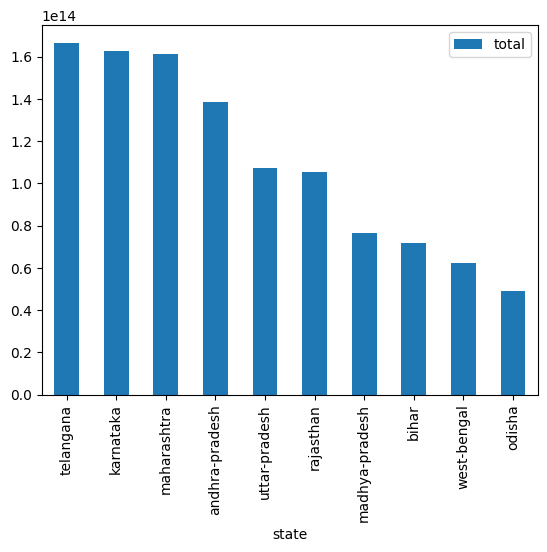

In [8]:
df1 = pd.read_sql("""
SELECT state, SUM(transaction_amount) AS total
FROM aggregated_transaction
GROUP BY state
ORDER BY total DESC LIMIT 10
""", conn)

df1.plot(kind='bar', x='state', y='total')
plt.show()

Why this chart?
To compare transaction amounts across states  

Insight:
Top states contribute significantly to total transactions  

Business Impact: 
Helps companies target high-performing regions  

Hypothesis 1

H0: Transaction amount does not depend on transaction count  
H1: Transaction amount depends on transaction count  

In [9]:
df['avg_value'] = df['transaction_amount'] / df['transaction_count']

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[['year','quarter','transaction_count','avg_value']]
y = df['transaction_amount']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

lr = LinearRegression()
lr.fit(X_train,y_train)

y_pred_lr = lr.predict(X_test)

In [13]:
from sklearn.metrics import r2_score, mean_squared_error

print(r2_score(y_test,y_pred_lr))
print(mean_squared_error(y_test,y_pred_lr))

0.4809589342569447
3.845846666212094e+22


In [14]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train,y_train)

y_pred_rf = rf.predict(X_test)
print(r2_score(y_test,y_pred_rf))

0.9998835189954891


In [16]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor()
dt.fit(X_train,y_train)

y_pred_dt = dt.predict(X_test)
print(r2_score(y_test,y_pred_dt))

0.9999989902823241


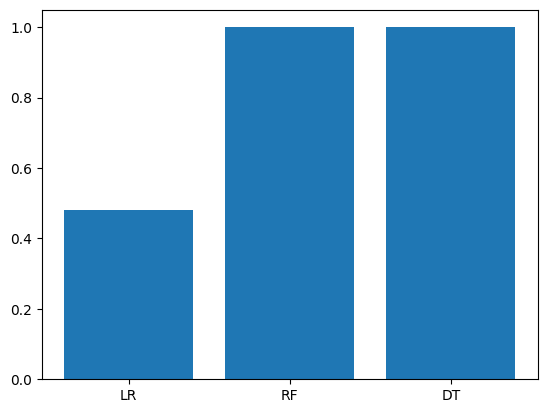

In [17]:
models = ['LR','RF','DT']
scores = [
    r2_score(y_test,y_pred_lr),
    r2_score(y_test,y_pred_rf),
    r2_score(y_test,y_pred_dt)
]

plt.bar(models,scores)
plt.show()

Conclusion

This project successfully analyzed PhonePe transaction data and built machine learning models to predict transaction amounts. Random Forest performed best and can be used for forecasting and business planning.